# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [6]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

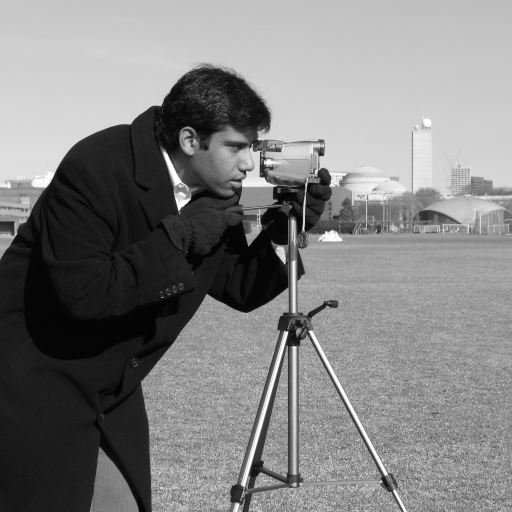

In [7]:
# ── Load image ────────────────────────────────────
camera = Image.fromarray(data.camera())
display(camera)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [8]:
# Get the size of the image
width, height = camera.size
print("Original size:", (width, height))

# scaling factors
cx = 2
cy = 2

Original size: (512, 512)


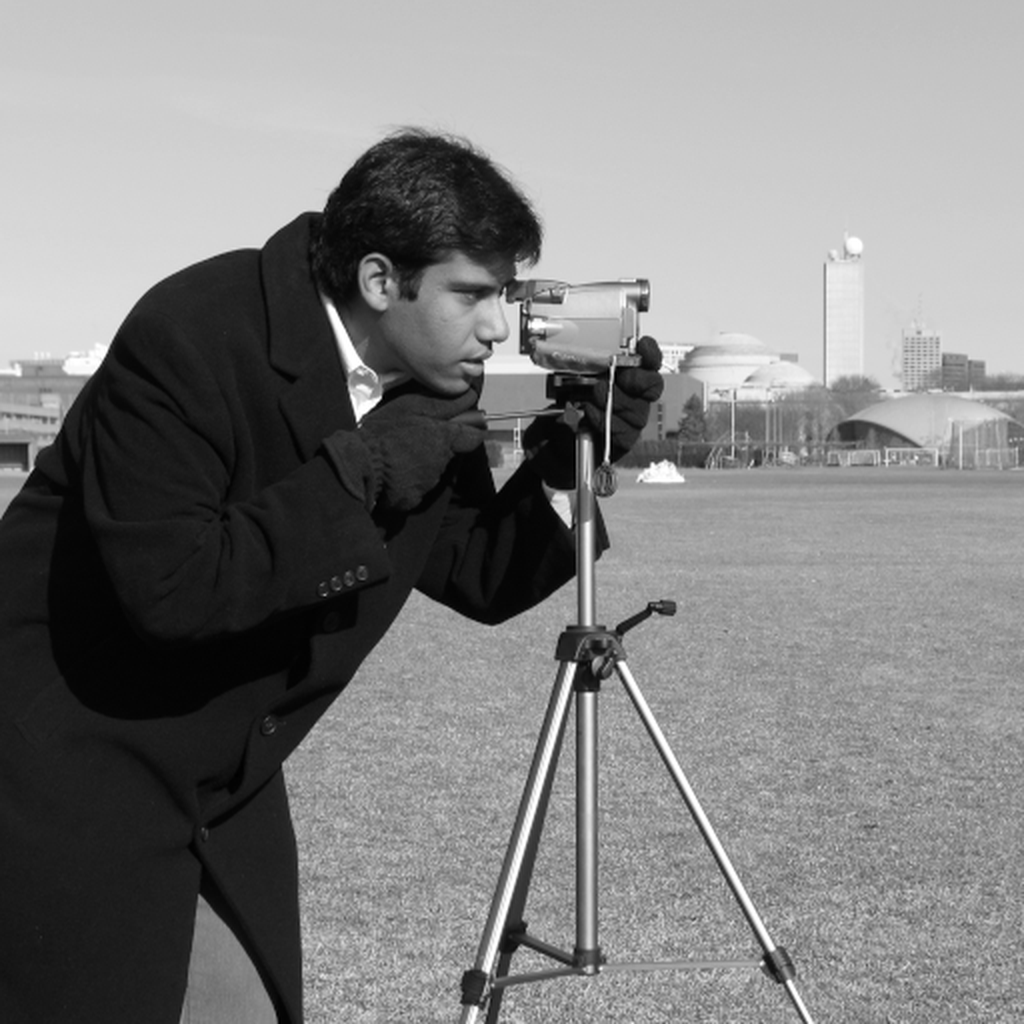

In [9]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
new_width = int(width * cx)
new_height = int(height * cy)

scaled_img = camera.resize((new_width, new_height), Image.Resampling.LANCZOS)
display(scaled_img)

In [11]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", camera.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

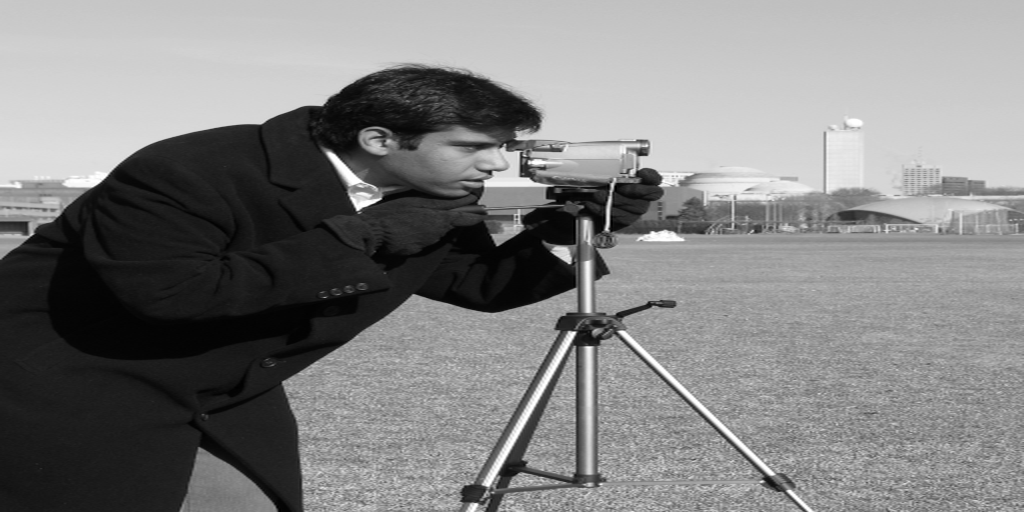

In [12]:
# Non-uniform scaling: cx = 2, cy = 1
cx = 2
cy = 1

non_uniform_size = (int(width * cx), int(height * cy))
non_uniform_img = camera.resize(non_uniform_size, Image.Resampling.LANCZOS)

display(non_uniform_img)

In [14]:
# Save the horizontally stretched image
non_uniform_img.save("task1_1_non_uniform_scaled.jpg")

print("Original size:", camera.size)
print("Non-uniform scaled size:", non_uniform_img.size)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


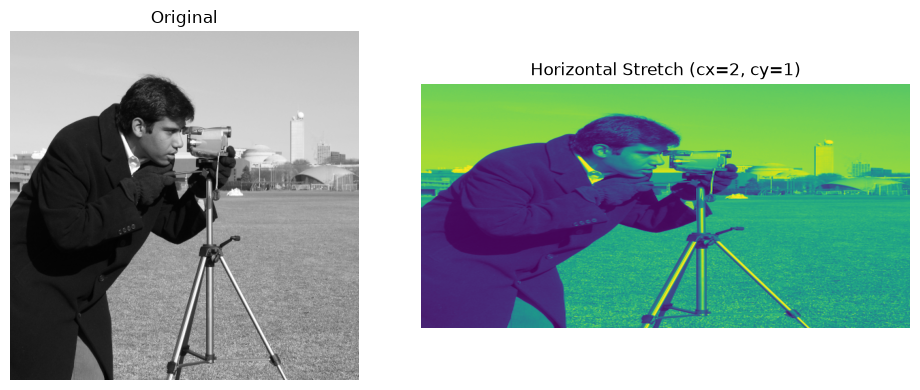

In [16]:
# Compare original and non-uniform scaling
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(camera, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(non_uniform_img)
plt.title("Horizontal Stretch (cx=2, cy=1)")
plt.axis("off")

plt.tight_layout()
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


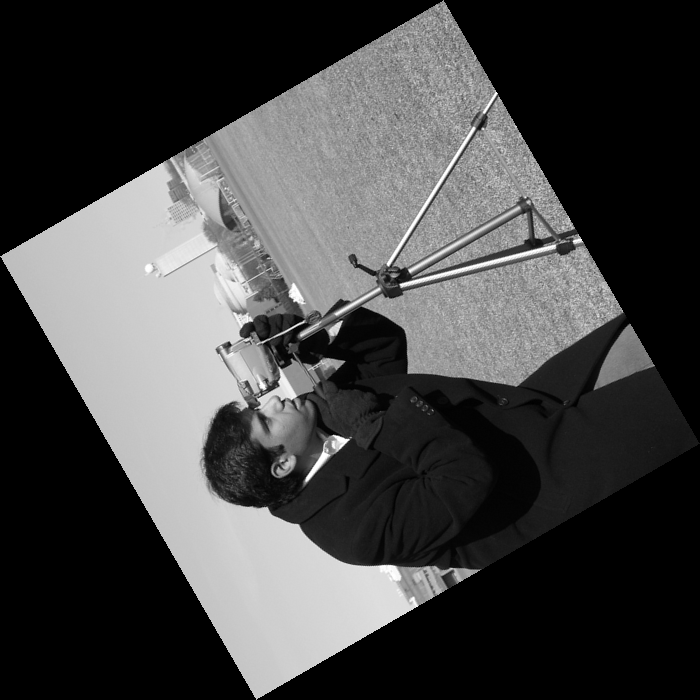

In [18]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = camera.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", camera.size)
print("Rotated size:", rotated_img.size)

display(rotated_img)

### 3. Shear

In [19]:
# -- c. Get the image dimensions ────────────────────
width, height = camera.size
print("Width:", width)
print("Height:", height)

Width: 512
Height: 512


In [20]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

# Increase canvas width so the full sheared image fits
new_width = int(width + abs(shear_factor) * height)
new_height = height

print("Shear factor:", shear_factor)
print("New canvas size:", (new_width, new_height))

Shear factor: 0.5
New canvas size: (768, 512)


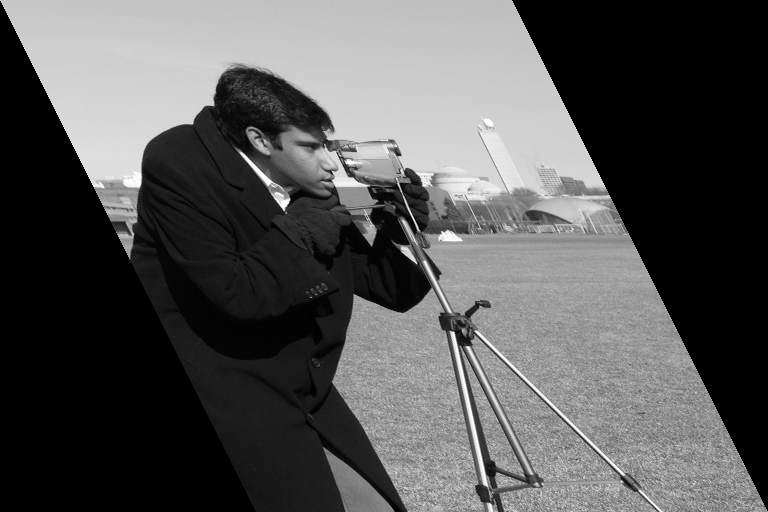

In [21]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = camera.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shear_factor, 0,
     0,  1,            0),
    resample=Image.Resampling.BICUBIC
)

display(sheared_img)

In [23]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", camera.size)
print("Sheared size:", sheared_img.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

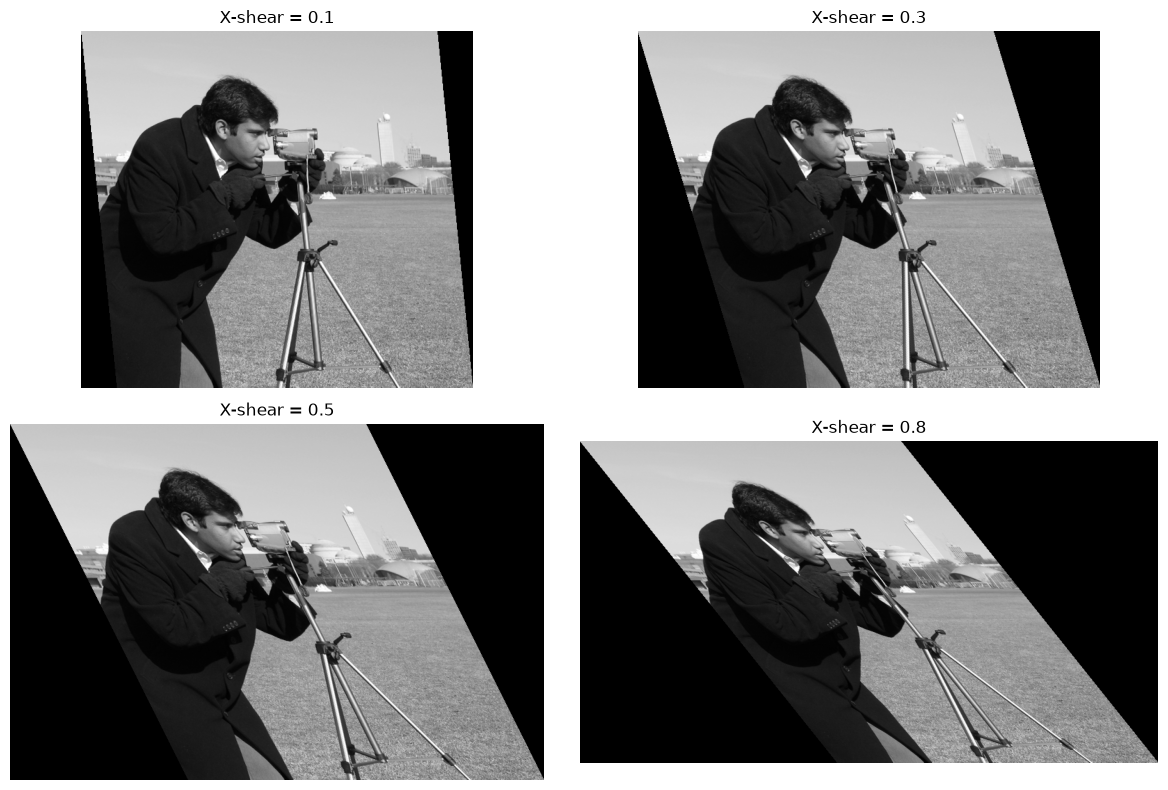

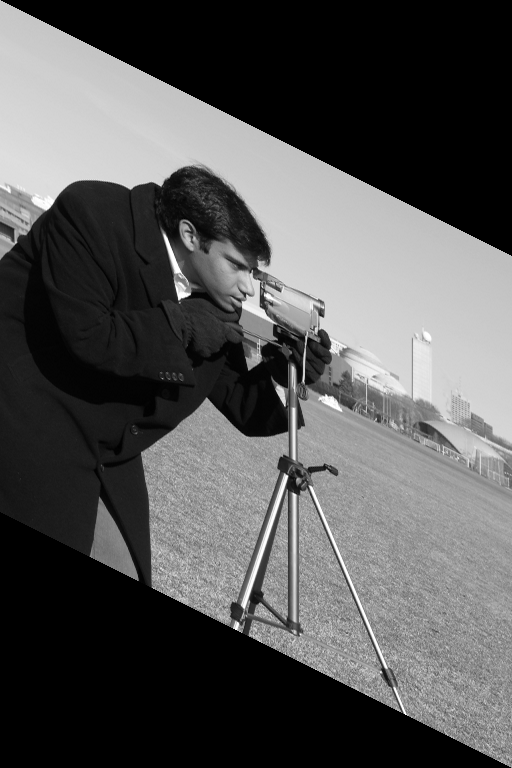

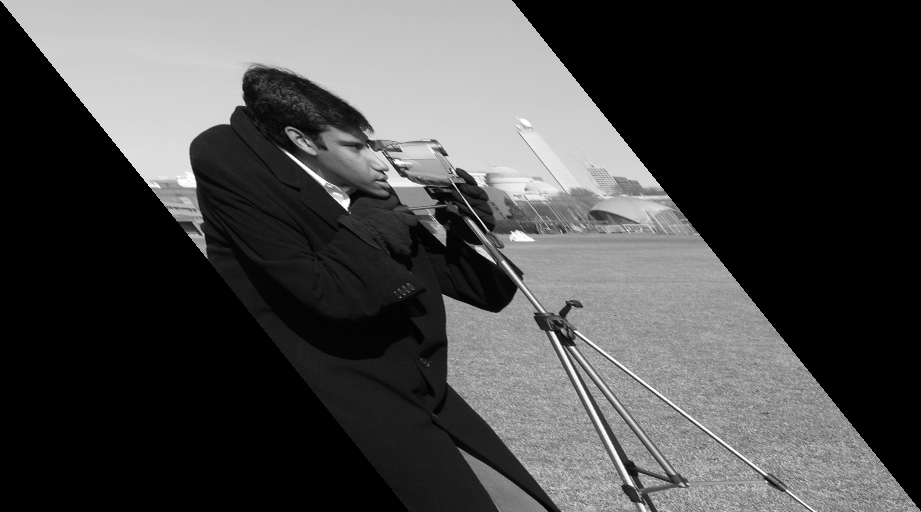

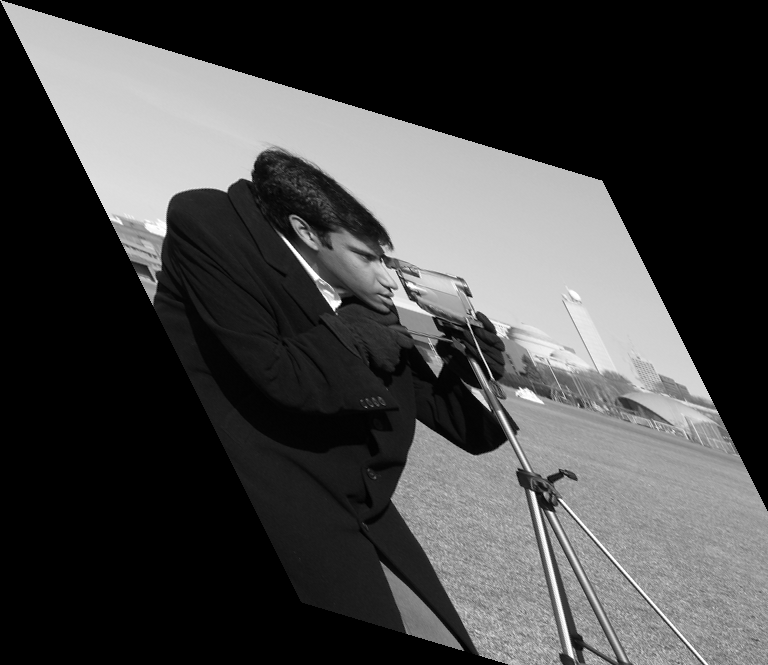

In [24]:
# 1. Try different X-axis shear factors
factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(12, 8))

for i, sh in enumerate(factors, 1):
    # Update the canvas size to match the current shear factor
    canvas_w = int(width + abs(sh) * height)

    test_img = camera.transform(
        (canvas_w, height),
        Image.Transform.AFFINE,
        (1, -sh, 0,
         0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    plt.subplot(2, 2, i)
    plt.imshow(test_img, cmap="gray")
    plt.title(f"X-shear = {sh}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# 2. Try Y-axis shear
shy = 0.5
canvas_h = int(height + abs(shy) * width)

y_sheared = camera.transform(
    (width, canvas_h),
    Image.Transform.AFFINE,
    (1, 0, 0,
     -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(y_sheared)


# 3. Update the canvas multiplier to match a new factor
shear_factor = 0.8
new_width = int(width + abs(shear_factor) * height)
new_height = height

new_shear = camera.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shear_factor, 0,
     0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(new_shear)


# 4. Combine X and Y shear in one matrix
shear_x = 0.5
shear_y = 0.3

combined_width = int(width + abs(shear_x) * height)
combined_height = int(height + abs(shear_y) * width)

combined_shear = camera.transform(
    (combined_width, combined_height),
    Image.Transform.AFFINE,
    (1, -shear_x, 0,
     -shear_y, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(combined_shear)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

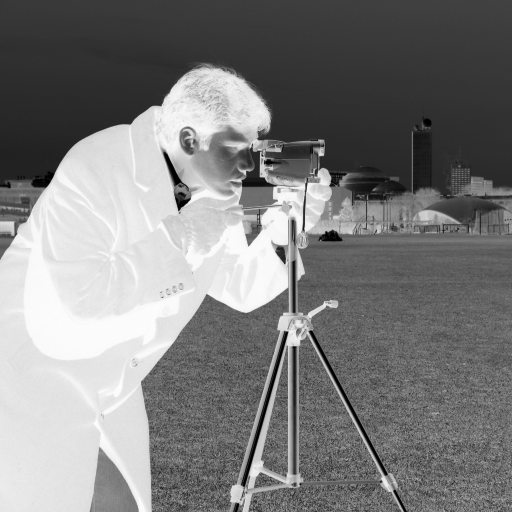

In [25]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(camera, dtype=np.uint8)
negative_arr = 255 - arr
negative_np = Image.fromarray(negative_arr)

negative_np.save("task2_1_negative_numpy.jpg")
display(negative_np)

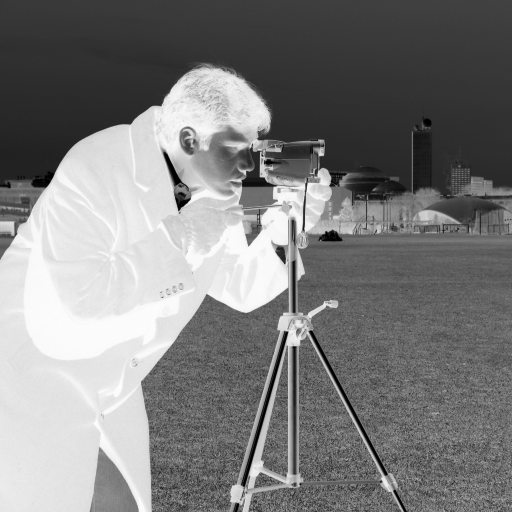

In [26]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(camera)

negative_pil.save("task2_1_negative_pil.jpg")
display(negative_pil)

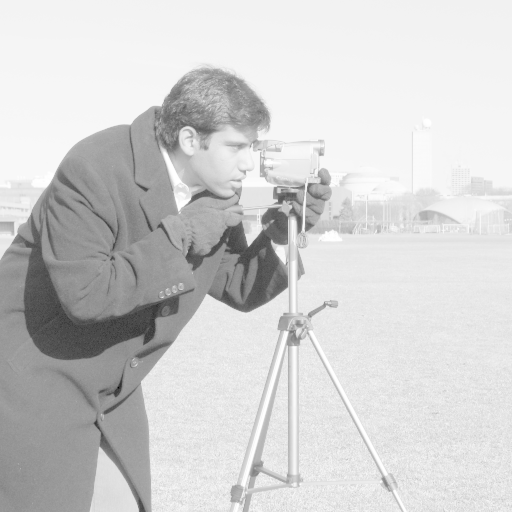

In [27]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)
arr_float = np.array(camera, dtype=np.float32)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log1p(arr_float)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_transformed_arr)
log_img.save("task2_2_log.jpg")

display(log_img)

Gamma: 0.5


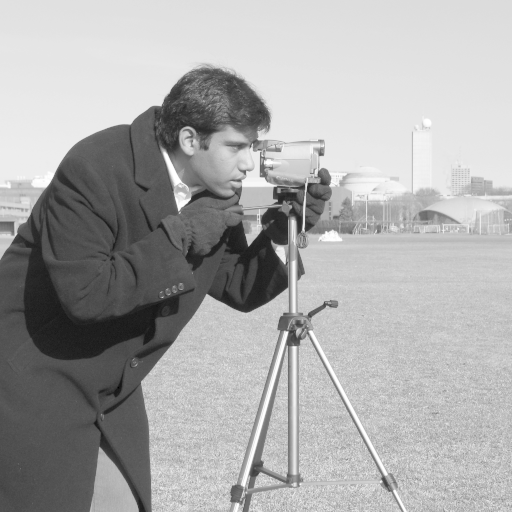

In [28]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

arr_float = np.array(camera, dtype=np.float32) / 255.0
gamma_arr = 255 * np.power(arr_float, gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)
gamma_img.save("task2_3_gamma.jpg")

print("Gamma:", gamma)
display(gamma_img)

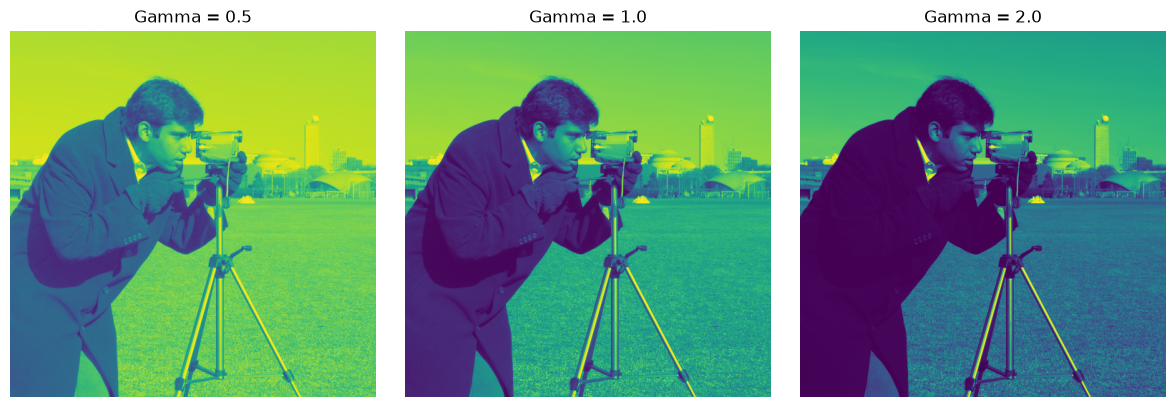

Gamma < 1 makes the image brighter.
Gamma = 1 keeps the image unchanged.
Gamma > 1 makes the image darker.


In [29]:
# Comparing different gamma values
gamma_values = [0.5, 1.0, 2.0]

plt.figure(figsize=(12, 4))

for i, gamma in enumerate(gamma_values, 1):
    corrected = 255 * np.power(
        np.array(camera, dtype=np.float32) / 255.0,
        gamma
    )
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)

    plt.subplot(1, 3, i)
    plt.imshow(corrected)
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Gamma < 1 makes the image brighter.")
print("Gamma = 1 keeps the image unchanged.")
print("Gamma > 1 makes the image darker.")